## The Multi-Armed Bandit Problem

The Multi-Armed Bandit problem is a classic dilemma in probability theory and machine learning. It involves an agent who, at each of a sequence of trials, must choose one out of several "arms" (or actions) to play. Each arm provides a random reward from an unknown probability distribution. The objective of the agent is to maximize the cumulative reward over a series of trials.

<img src="https://drive.google.com/uc?id=1xbF_kbUu0RYJimdEKS3yOnP5sutqk1Ck" alt="slot_machine" width="500">

### Key Concepts:

*   **Bandits (or Arms)**: These represent different choices or actions available to the agent. Each bandit has an associated, often unknown, reward distribution.
*   **Rewards**: When an arm is pulled, a reward is received, drawn from that arm's specific distribution. The goal is to maximize the sum of these rewards.
*   **Trials**: The problem unfolds over a series of discrete time steps, or trials.
*   **Exploration vs. Exploitation**: This is the core trade-off:
    *   **Exploitation**: Choosing the arm that currently appears to be the best (based on past experience) to maximize immediate reward.
    *   **Exploration**: Choosing a less-known arm to gather more information about its potential reward, which might lead to higher rewards in the long run.

### Why is it a problem?

If the reward distributions of the arms were known, the agent would simply always choose the arm with the highest expected reward. However, since these distributions are unknown, the agent must learn them through experience. This means the agent has to balance trying out new arms (exploration) with sticking to arms that have performed well so far (exploitation).

### Common Algorithms:

Several algorithms are designed to address the exploration-exploitation trade-off problems, such as:

*   **Epsilon-Greedy**: With probability $\epsilon$ (epsilon), explore by choosing a random arm; otherwise, exploit by choosing the arm with the highest estimated average reward.
*   **Upper Confidence Bound (UCB)**: Selects arms based on their estimated average reward plus an exploration bonus that favors arms that have been sampled fewer times or have high variance in their rewards.

### Applications:

Multi-armed bandit problems are highly relevant in various fields, including:

*   **Online Advertising**: Deciding which ad to show to a user to maximize click-through rates.
*   **Clinical Trials**: Choosing which drug treatment to administer to patients to maximize success rates.
*   **Website Optimization (A/B Testing)**: Deciding which version of a webpage layout to use to maximize user engagement.
*   **Resource Allocation**: Allocating limited resources to different projects with uncertain outcomes.

You can know more about the problem in this [video](https://youtu.be/8CquWcViBfg).


We will compare the performance of UCB1 and Epsilon greedy strategies for this problem in the following experiments.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

### Bandit Reward Distributions

To analyze the performance of the UCB and Epsilon-Greedy algorithms, we use six distinct probability distributions for the bandits. Below are the properties and means for each:

---

#### 1. Uniform Distribution (Bandit 0)
Rewards are spread evenly between $a$ and $b$. Every value in this range has an equal probability of being selected, representing a scenario with maximum uncertainty within a bounded interval.
- **Parameters**: $\text{Mean} = 8.0, \text{Range} = 6.0$, resulting in $[5, 11]$.
- **Mean**: $E[X] = \frac{a + b}{2} = 8.0$

#### 2. Trapezoidal Distribution (Bandit 1)
This distribution is a hybrid: it features a central plateau of maximum probability (the rectangle) and linear ramps (triangles) on either side. It models processes where rewards are most likely within a specific range but can taper off gradually to lower/higher limits.
- **Parameters**: $a=4, b=6, c=14, d=16$.
- **Mean**: $E[X] = \frac{1}{3} \frac{d^2+c^2+cd - a^2-b^2-ab}{d+c-a-b} = 10.0$

#### 3. Beta Distribution (Bandit 2)
Highly versatile, the Beta distribution is defined on $[0, 1]$ and shaped by $\alpha$ and $\beta$. With $\alpha=3$ and $\beta=5$, it is slightly right-skewed, meaning lower rewards within its range are more common than very high ones.
- **Parameters**: $\alpha=3, \beta=5$, scaled by $S=24$.
- **Mean**: $E[X] = S \times \frac{\alpha}{\alpha + \beta} = 24 \times \frac{3}{8} = 9.0$

#### 4. Truncated Normal Distribution (Bandit 3)
This starts as a standard Gaussian 'bell curve' but is forcibly cut off at specific boundaries. It models systems with a central 'target' reward but where physical or logical constraints prevent extreme outliers.
- **Parameters**: $\mu=9, \sigma=2$, restricted to $[0, 15]$.
- **Mean**: For symmetric truncation around $\mu$, $E[X] \approx \mu = 9.0$

#### 5. Triangular Distribution (Bandit 4)
Often used when data is limited, it is defined by a minimum, a maximum, and a peak (mode). It provides a simple way to model a distribution that isn't symmetric, as seen here where the peak is closer to the right boundary.
- **Parameters**: $a=2, c=8, b=11$.
- **Mean**: $E[X] = \frac{a + b + c}{3} = 7.0$

#### 6. Wigner Semicircle Distribution (Bandit 5)
Originating from random matrix theory, its probability density function forms a semicircle. It is unique because its density drops to zero very sharply at the radius limits, creating a very 'tight' and bounded distribution.
- **Parameters**: Radius $R=8$ (centered at $8$).
- **Mean**: $E[X] = R = 8.0$

In [2]:
import numpy as np

# Global Constants for Bandit Distributions
# 0. Uniform Distribution
BANDIT_0_UNIFORM_MEAN = 8
BANDIT_0_RANGE = 6

# 1. Trapezoidal Distribution (Custom Bounded - Numpy implementation)
BANDIT_1_TRAPZ_A = 4
BANDIT_1_TRAPZ_B = 6
BANDIT_1_TRAPZ_C = 14
BANDIT_1_TRAPZ_D = 16
# Height of the trapezoid to make area=1
# Area = 0.5 * ( (D-A) + (C-B) ) * H = 1
BANDIT_1_HEIGHT = 1 / (0.5 * ((BANDIT_1_TRAPZ_D - BANDIT_1_TRAPZ_A) + (BANDIT_1_TRAPZ_C - BANDIT_1_TRAPZ_B)))

# 2. Beta Distribution
BANDIT_2_BETA_A = 3
BANDIT_2_BETA_B = 5
BANDIT_2_BETA_SCALE = 24

# 3. Truncated Normal Distribution (Numpy implementation)
BANDIT_3_TNORM_MU = 9
BANDIT_3_TNORM_SIGMA = 2
BANDIT_3_LOWER, BANDIT_3_UPPER = 0, 15

# 4. Triangular Distribution
BANDIT_4_TRI_LEFT = 2
BANDIT_4_TRI_MODE = 8
BANDIT_4_TRI_RIGHT = 11

# 5. Wigner Semicircle Distribution
BANDIT_5_R = 8

# Calculate True Means (Analytical Formulas)
TRUE_MEANS = [
    BANDIT_0_UNIFORM_MEAN,
    # Trapezoid mean calculation
    (1/3) * ((BANDIT_1_TRAPZ_D**2 + BANDIT_1_TRAPZ_C**2 + BANDIT_1_TRAPZ_D*BANDIT_1_TRAPZ_C - BANDIT_1_TRAPZ_A**2 - BANDIT_1_TRAPZ_B**2 - BANDIT_1_TRAPZ_A*BANDIT_1_TRAPZ_B) / (BANDIT_1_TRAPZ_D + BANDIT_1_TRAPZ_C - BANDIT_1_TRAPZ_A - BANDIT_1_TRAPZ_B)),
    (BANDIT_2_BETA_A / (BANDIT_2_BETA_A + BANDIT_2_BETA_B)) * BANDIT_2_BETA_SCALE,
    BANDIT_3_TNORM_MU,
    (BANDIT_4_TRI_LEFT + BANDIT_4_TRI_MODE + BANDIT_4_TRI_RIGHT) / 3,
    BANDIT_5_R
]

print("True Means:", [round(m, 2) for m in TRUE_MEANS])
OPTIMAL_MEAN = max(TRUE_MEANS)

def pull_bandit(bandit):
    if bandit == 0:
        return np.random.uniform(BANDIT_0_UNIFORM_MEAN - (BANDIT_0_RANGE/2), BANDIT_0_UNIFORM_MEAN + (BANDIT_0_RANGE/2))
    elif bandit == 1:
        # Trapezoid Rejection Sampling
        while True:
            x = np.random.uniform(BANDIT_1_TRAPZ_A, BANDIT_1_TRAPZ_D)
            y = np.random.uniform(0, BANDIT_1_HEIGHT)
            if x < BANDIT_1_TRAPZ_B:
                pdf_val = BANDIT_1_HEIGHT * (x - BANDIT_1_TRAPZ_A) / (BANDIT_1_TRAPZ_B - BANDIT_1_TRAPZ_A)
            elif x <= BANDIT_1_TRAPZ_C:
                pdf_val = BANDIT_1_HEIGHT
            else:
                pdf_val = BANDIT_1_HEIGHT * (BANDIT_1_TRAPZ_D - x) / (BANDIT_1_TRAPZ_D - BANDIT_1_TRAPZ_C)
            if y <= pdf_val:
                return x
    elif bandit == 2:
        return np.random.beta(BANDIT_2_BETA_A, BANDIT_2_BETA_B) * BANDIT_2_BETA_SCALE
    elif bandit == 3:
        # Truncated Normal Sampling
        while True:
            x = np.random.normal(BANDIT_3_TNORM_MU, BANDIT_3_TNORM_SIGMA)
            if BANDIT_3_LOWER <= x <= BANDIT_3_UPPER:
                return x
    elif bandit == 4:
        return np.random.triangular(BANDIT_4_TRI_LEFT, BANDIT_4_TRI_MODE, BANDIT_4_TRI_RIGHT)
    elif bandit == 5:
        while True:
            x = np.random.uniform(-1, 1)
            y = np.random.uniform(0, 2/np.pi)
            if y <= (2/np.pi) * np.sqrt(1 - x**2):
                return (x * BANDIT_5_R) + BANDIT_5_R
    else:
        return None

True Means: [8, 10.0, 9.0, 9, 7.0, 8]


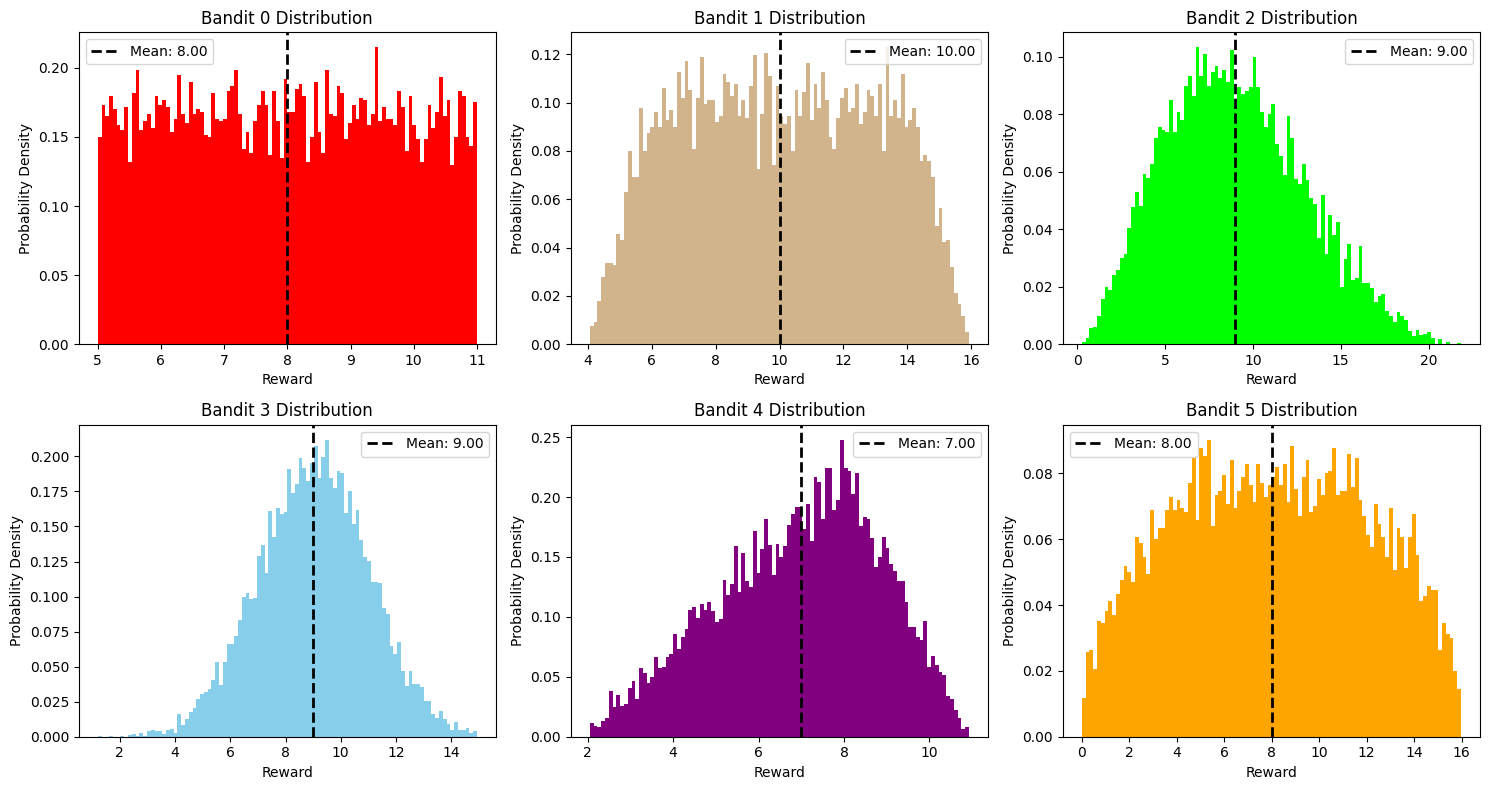

In [3]:
def plot_bandit_distributions(num_samples=10000, bins=100, num_bandits=6):
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    axs = axs.flatten()
    colors = ['red', 'tan', 'lime', 'skyblue', 'purple', 'orange']
    for i in range(num_bandits):
        x = np.zeros(num_samples)
        for j in range(num_samples):
            x[j] = pull_bandit(i)
        # Using adaptive range based on the data to make distributions clearer
        axs[i].hist(x, density=True, bins=bins, color=colors[i])
        # Add a vertical line for the true mean
        axs[i].axvline(TRUE_MEANS[i], color='black', linestyle='--', linewidth=2, label=f'Mean: {TRUE_MEANS[i]:.2f}')
        axs[i].set_title(f'Bandit {i} Distribution')
        axs[i].set_xlabel('Reward')
        axs[i].set_ylabel('Probability Density')
        axs[i].legend()
    plt.tight_layout()
    plt.show()
plot_bandit_distributions()

### The UCB Algorithm

The **Upper Confidence Bound (UCB1)** algorithm is based on the principle of "optimism in the face of uncertainty." It aims to solve the exploration-exploitation trade-off by assigning a value to each arm that represents a plausible upper limit on its true mean reward.

#### 1. Hoeffding's Inequality
UCB1 is derived from **Hoeffding's Inequality**, which provides an upper bound on the probability that the sum of bounded independent random variables deviates from its expected value. For a random variable $X_i \in [0, 1]$:

$$P\left( |\bar{X}_i - \mu_i| \ge \delta \right) \le 2e^{-2n_i\delta^2}$$

Where:
- $\bar{X}_i$ is the empirical mean of arm $i$.
- $\mu_i$ is the true mean of arm $i$.
- $n_i$ is the number of times arm $i$ has been pulled.
- $\delta$ is the confidence width.

#### 2. The Upper Bound Calculation
In the UCB1 algorithm, we want the true mean $\mu_i$ to be less than our estimate $\bar{X}_i + \delta$ with high probability. By setting the probability of failure to $1/t^2$ (where $t$ is the total number of trials), we solve for $\delta$:

$$2e^{-2n_i\delta^2} = \frac{1}{t} \implies \delta_i = \sqrt{\frac{2 \ln t}{n_i}}$$

#### 3. The UCB1 Selection Rule (Weighted Implementation)
As seen in our simulation code, we use a weighted version of the selection rule to provide finer control over the agent's behavior. At each time step $t$, the agent selects the arm $i$ that maximizes:

$$\text{UCB}_i(t) = (\text{Exploitation Weight} \times \bar{X}_i) + (\text{Exploration Weight} \times \sqrt{\frac{2 \ln t}{n_i}})$$

- **Exploitation Term ($w_{exploit} \times \bar{X}_i$)**: Favors arms that have performed well in the past. The **Exploitation Weight** (defined as $1 - \text{exploration_weight}$) allows us to scale the importance of known historical performance.
- **Exploration Term ($w_{explore} \times \sqrt{\frac{2 \ln t}{n_i}}$)**: Favors arms that have not been pulled many times. The **Exploration Weight** allows us to manually tune how much the agent prioritizes gathering new information. As $t$ increases, this term grows slowly for all arms, but as $n_i$ increases for a specific arm, its exploration bonus shrinks, reflecting increased certainty.

In [4]:
def upper_confidence_bound(max_trails=10000, resolution=100, num_bandits=6, exploration_weight=0.5):
    exploitation_weight = 1 - exploration_weight
    num_pulls = np.zeros(num_bandits)
    total_rewards = np.zeros(num_bandits)
    average_rewards = np.zeros(num_bandits)
    ucb_values = np.ones(num_bandits) * np.inf
    total_cumulative_reward = 0
    avg_reward_history = []

    for n in range(1, max_trails + 1):
        current_bandit_to_pull = np.argmax(ucb_values)
        reward = pull_bandit(current_bandit_to_pull)

        num_pulls[current_bandit_to_pull] += 1
        total_rewards[current_bandit_to_pull] += reward
        total_cumulative_reward += reward
        average_rewards[current_bandit_to_pull] = total_rewards[current_bandit_to_pull] / num_pulls[current_bandit_to_pull]

        for i in range(num_bandits):
            if num_pulls[i] > 0:
                exploration_term = exploration_weight * np.sqrt((2 * np.log(n)) / num_pulls[i])
                ucb_values[i] = (average_rewards[i] * exploitation_weight) + exploration_term
            else:
                ucb_values[i] = np.inf # Ensure untouched arms are prioritized for exploration

        if n % resolution == 0:
            avg_reward_history.append(total_cumulative_reward / n)

    return avg_reward_history

### The Epsilon-Greedy Algorithm

The **Epsilon-Greedy** algorithm is one of the simplest yet most effective strategies for the multi-armed bandit problem. It balances exploration and exploitation using a single parameter, $\epsilon$ (epsilon), which represents the probability of exploring.

#### 1. The Selection Rule
At each trial $t$, the agent flips a biased coin:
- **Exploitation (Probability $1 - \epsilon$):** The agent chooses the arm with the highest current empirical mean reward (the "greedy" action).
  $$a_t = \text{argmax}_{i} \bar{X}_i$$
- **Exploration (Probability $\epsilon$):** The agent ignores what it has learned and chooses an arm uniformly at random from all available options.

#### 2. The Trade-off
- **A high $\epsilon$** (e.g., 0.5) means the agent spends a lot of time gathering information. While it will find the best arm quickly, it will continue to pull sub-optimal arms frequently, limiting its total reward.
- **A low $\epsilon$** (e.g., 0.01) means the agent exploits its current knowledge heavily. It may take a long time to discover which arm is truly the best, but once it does, it spends most of its time pulling that arm.

#### 3. Limitations
Unlike UCB, standard Epsilon-Greedy does not account for the *uncertainty* or variance of an arm's reward. It treats an arm pulled once the same as an arm pulled a thousand times if their average rewards are currently equal.

In [5]:
def epsilon_greedy(max_trails=10000, num_bandits=6, resolution = 100, epsilon=0.1):
    bandits_pulled = np.zeros(num_bandits)
    bandits_total_reward = np.zeros(num_bandits)
    bandits_average_reward = np.zeros(num_bandits)
    total_reward = 0
    current_bandit = 0
    avg_reward_history = []

    for n in range(1, max_trails+1):
        reward = pull_bandit(current_bandit)
        bandits_pulled[current_bandit] += 1
        bandits_total_reward[current_bandit] += reward
        total_reward += reward
        bandits_average_reward[current_bandit] = bandits_total_reward[current_bandit]/bandits_pulled[current_bandit]

        best_bandit = np.argmax(bandits_average_reward)
        if n % resolution == 0:
            avg_reward_history.append(total_reward/n)

        if np.random.uniform() > epsilon:
            current_bandit = best_bandit
        else:
            # Include the best arm in the exploration phase
            current_bandit = np.random.choice(range(num_bandits))

    return avg_reward_history

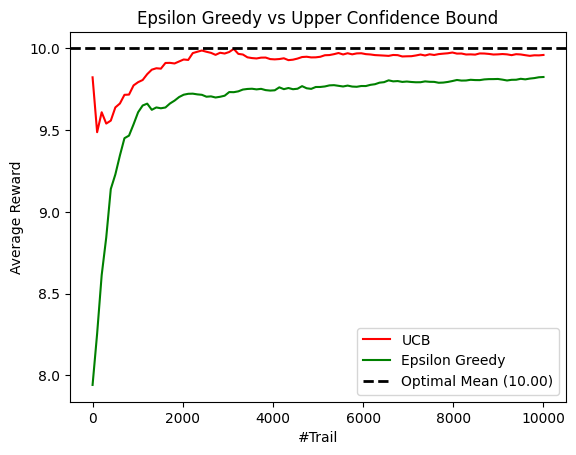

In [6]:
# Run simulations with default parameters for individual plotting
ucb_avg_reward = upper_confidence_bound()
epsilon_greedy_avg_reward = epsilon_greedy()

t = np.linspace(0, 10000, 100)
plt.plot(t, ucb_avg_reward, color="red", label="UCB")
plt.plot(t, epsilon_greedy_avg_reward, color="green", label="Epsilon Greedy")
plt.axhline(y=OPTIMAL_MEAN, color='black', linestyle='--', linewidth=2, zorder=5, label=f'Optimal Mean ({OPTIMAL_MEAN:.2f})')
plt.title("Epsilon Greedy vs Upper Confidence Bound")
plt.xlabel("#Trail")
plt.ylabel("Average Reward")
plt.legend(loc='lower right')
plt.show()

### High-Resolution TPU Simulation: Visualizing Convergence Density

To gain a deeper understanding of the algorithms beyond simple average performance, we use **JAX and TPU acceleration** to run 40 parallel simulations for each parameter configuration.

#### **Why Heatmaps?**
A single line plot only shows the mean outcome, which can hide significant variance or 'failed' runs. By generating 2D histograms (heatmaps), we can see the **density of outcomes**:
- **Vertical Spread**: Shows how much the reward varies across different random seeds at a specific trial.
- **Intensity (Color)**: Highlights where most simulations 'cluster.' A tight cluster around the optimal mean (10.0) indicates high reliability.
- **Ghost Bands**: Horizontal streaks below the optimal mean represent scenarios where the agent got stuck on a sub-optimal arm for an extended period.

#### **Experimental Goals**
1. **Observe Stability**: Contrast the 'tightness' of UCB1's convergence against the permanent variance of Epsilon-Greedy.
2. **Parameter Sensitivity**: Visually confirm how increasing $w$ or $\epsilon$ physically shifts the probability mass toward or away from the optimal reward.
3. **Identify 'Jump' Moments**: Spot the specific trials where UCB1 suddenly corrects its path from a sub-optimal arm to the best one.

Running TPU-optimized simulations...


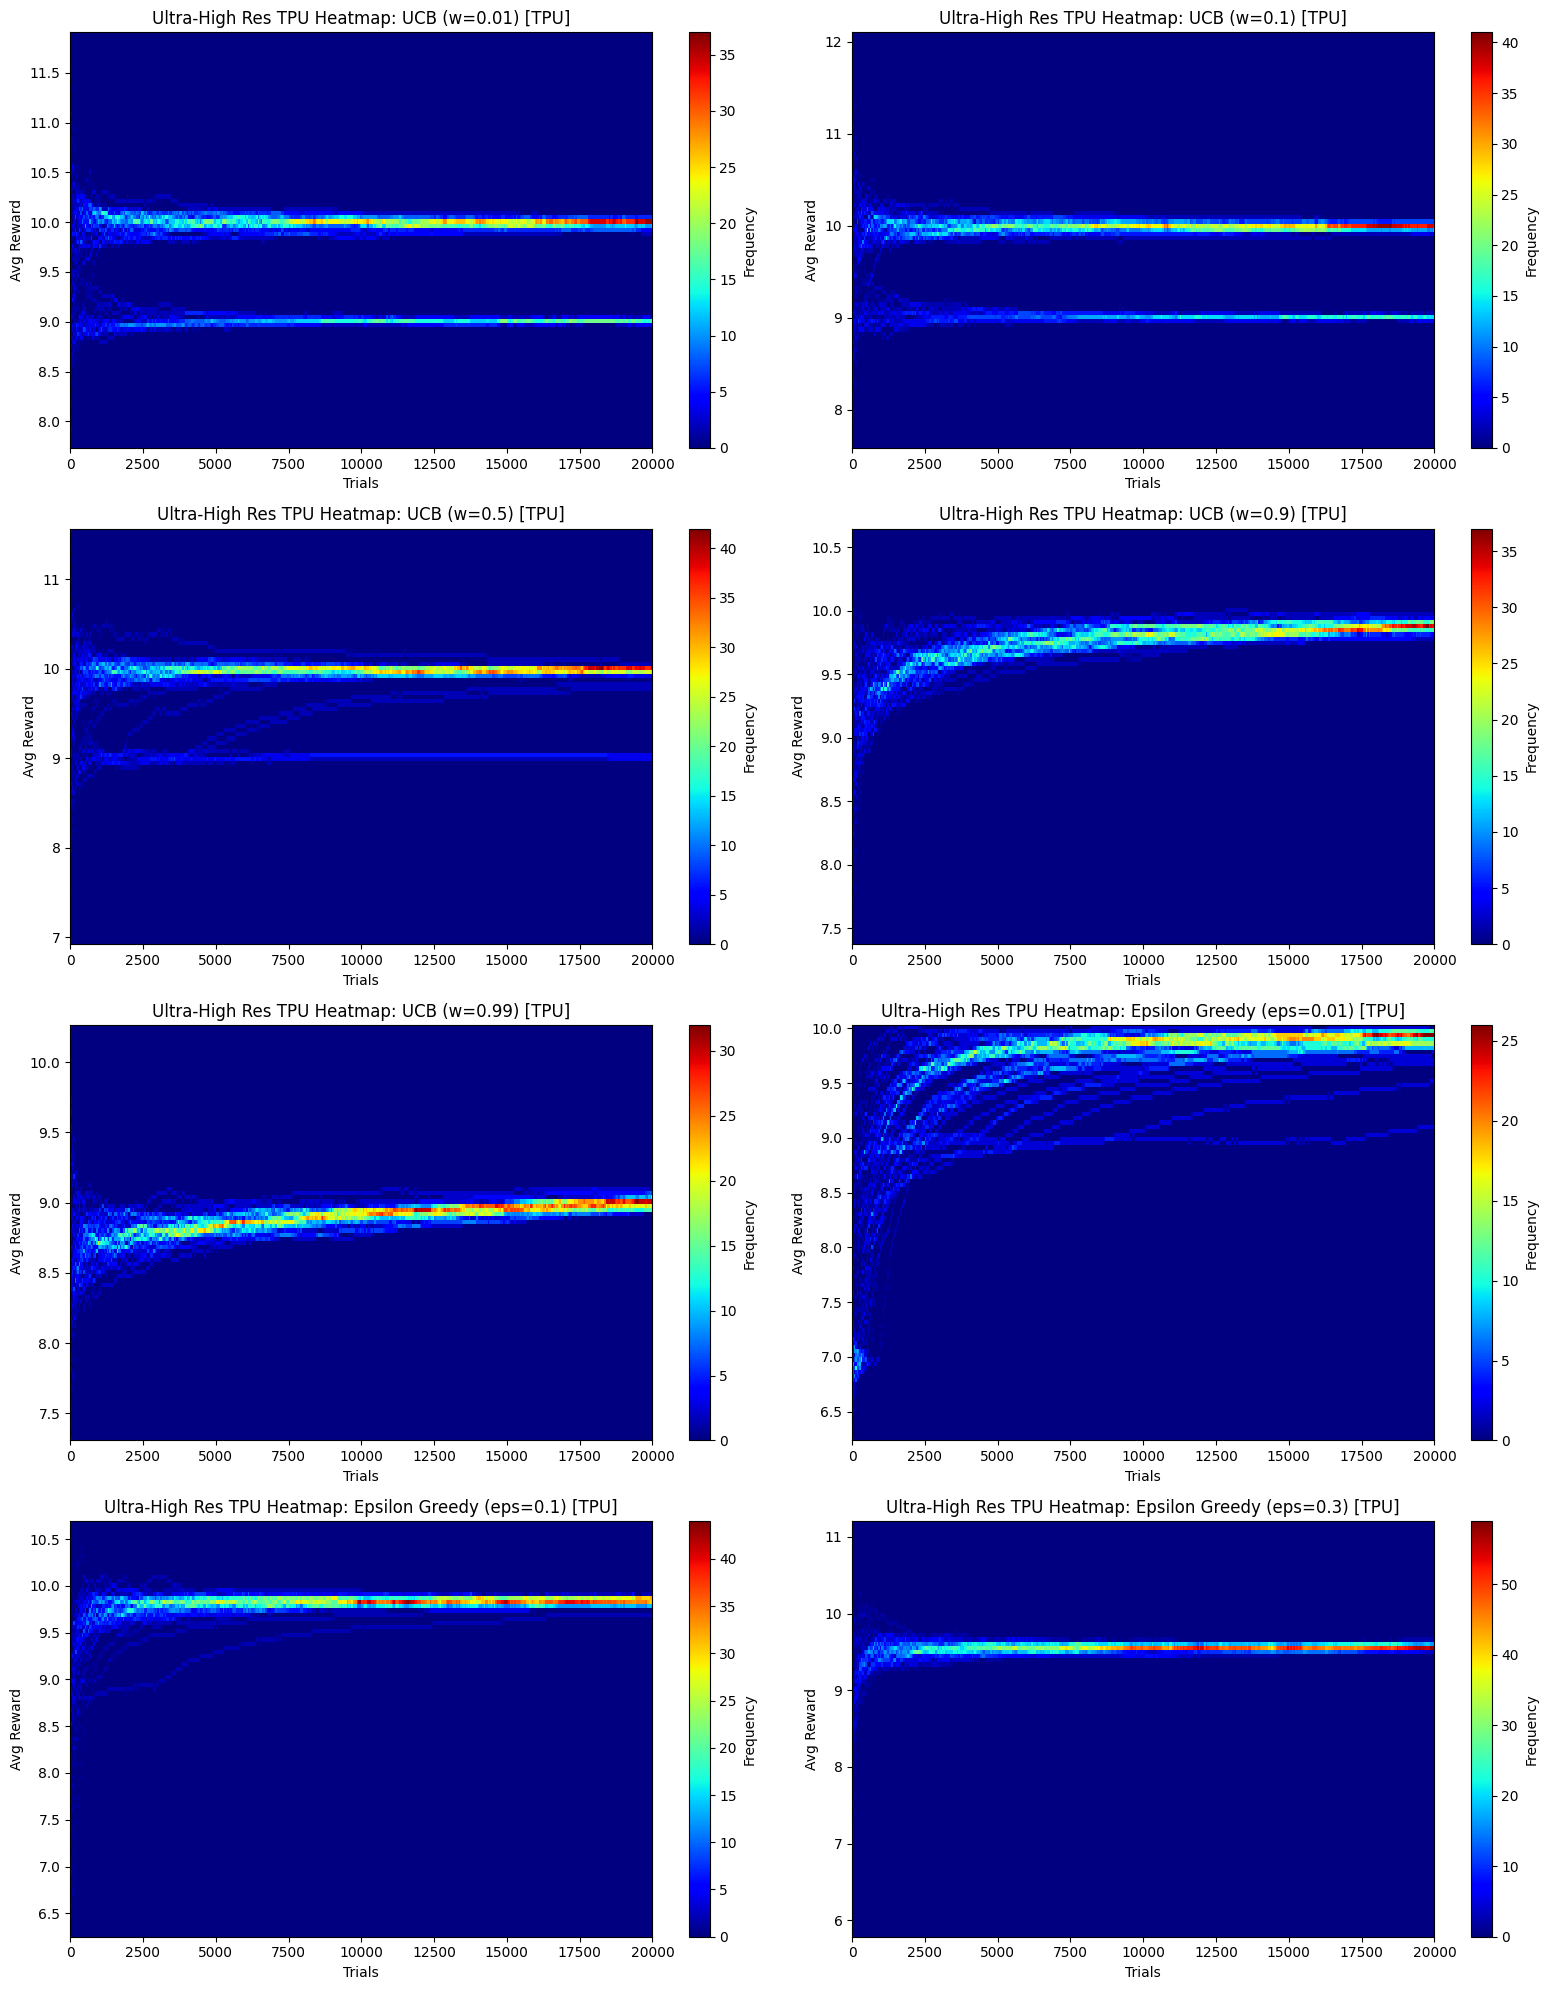

In [7]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

@jax.jit
def pull_bandit_jax(bandit_idx, key):
    return jax.lax.switch(bandit_idx, [
        lambda k: jax.random.uniform(k, minval=4.0, maxval=10.0),
        lambda k: jax.random.uniform(k, minval=4.0, maxval=16.0),
        lambda k: jax.random.beta(k, 3.0, 5.0) * 24.0,
        lambda k: jax.random.normal(k) * 2.0 + 9.0,
        lambda k: jax.random.uniform(k, minval=2.0, maxval=11.0),
        lambda k: jax.random.uniform(k, minval=0.0, maxval=20.0)
    ], key)

@jax.jit
def run_ucb_simulation_tpu(key, exploration_weight, max_trials=20000, num_bandits=6):
    def body_fn(state, _):
        key, counts, sums, totals, history, step = state
        key, subkey = jax.random.split(key)
        avg_rewards = sums / jnp.maximum(counts, 1.0)
        ucb_vals = jnp.where(counts > 0, (1 - exploration_weight) * avg_rewards + exploration_weight * jnp.sqrt(2 * jnp.log(step + 1) / counts), 1e9)
        chosen_bandit = jnp.argmax(ucb_vals)
        reward = pull_bandit_jax(chosen_bandit, subkey)
        new_counts = counts.at[chosen_bandit].add(1)
        new_sums = sums.at[chosen_bandit].add(reward)
        new_total = totals + reward
        record_val = jnp.where((step + 1) % 25 == 0, new_total / (step + 1), history[step // 25])
        new_history = history.at[step // 25].set(record_val)
        return (key, new_counts, new_sums, new_total, new_history, step + 1), None
    init_state = (key, jnp.zeros(num_bandits), jnp.zeros(num_bandits), 0.0, jnp.zeros(max_trials // 25), 0)
    final_state, _ = jax.lax.scan(body_fn, init_state, None, length=max_trials)
    return final_state[4]

@jax.jit
def run_epsilon_simulation_tpu(key, epsilon, max_trials=20000, num_bandits=6):
    def body_fn(state, _):
        key, counts, sums, totals, history, step = state
        key, subkey_choice, subkey_pull = jax.random.split(key, 3)
        avg_rewards = sums / jnp.maximum(counts, 1.0)
        best_bandit = jnp.argmax(avg_rewards)
        random_bandit = jax.random.randint(subkey_choice, (), 0, num_bandits)
        is_explore = jax.random.uniform(subkey_choice) < epsilon
        chosen_bandit = jnp.where(is_explore, random_bandit, best_bandit)
        reward = pull_bandit_jax(chosen_bandit, subkey_pull)
        new_counts = counts.at[chosen_bandit].add(1)
        new_sums = sums.at[chosen_bandit].add(reward)
        new_total = totals + reward
        record_val = jnp.where((step + 1) % 25 == 0, new_total / (step + 1), history[step // 25])
        new_history = history.at[step // 25].set(record_val)
        return (key, new_counts, new_sums, new_total, new_history, step + 1), None
    init_state = (key, jnp.zeros(num_bandits), jnp.zeros(num_bandits), 0.0, jnp.zeros(max_trials // 25), 0)
    final_state, _ = jax.lax.scan(body_fn, init_state, None, length=max_trials)
    return final_state[4]

run_parallel_ucb = jax.vmap(run_ucb_simulation_tpu, in_axes=(0, None))
run_parallel_epsilon = jax.vmap(run_epsilon_simulation_tpu, in_axes=(0, None))

master_key = jax.random.PRNGKey(42)
all_data = {}
ucb_params = [0.01 ,0.1, 0.5, 0.9, 0.99]
eps_params = [0.01, 0.1, 0.3]

print("Running TPU-optimized simulations...")
for w in ucb_params:
    keys = jax.random.split(master_key, 40)
    all_data[f"UCB (w={w}) [TPU]"] = np.array(run_parallel_ucb(keys, w))
for e in eps_params:
    keys = jax.random.split(master_key, 40)
    all_data[f"Epsilon Greedy (eps={e}) [TPU]"] = np.array(run_parallel_epsilon(keys, e))

# Calculate number of rows and columns for subplots
num_plots = len(all_data)
num_cols = 2
num_rows = 4

fig, axs = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 5))
axs = axs.flatten()

for i, (selection, data) in enumerate(all_data.items()):
    t = np.linspace(0, 20000, data.shape[1])
    ax = axs[i]
    heatmap = ax.hist2d(np.tile(t, (data.shape[0], 1)).flatten(), data.flatten(), bins=[400, 100], cmap='jet')
    fig.colorbar(heatmap[3], ax=ax, label='Frequency')
    ax.set_title(f"Ultra-High Res TPU Heatmap: {selection}")
    ax.set_xlabel("Trials")
    ax.set_ylabel("Avg Reward")

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

### Analysis of Simulation Results

Based on the high-resolution TPU heatmaps, we can observe distinct behaviors between the two algorithms across different parameter settings:

#### **1. Upper Confidence Bound (UCB1)**
*   **Pros:**
    *   **Efficient Convergence:** For optimal weights (e.g., $w=0.1$ to $0.5$), UCB quickly identifies the best arm (Bandit 1, Mean=10) and the average reward converges tightly around the optimal value.
    *   **Mathematical Bound:** Unlike Epsilon-Greedy, UCB has a sub-linear regret bound. It reduces exploration naturally as it becomes more confident, leading to higher long-term stability.
    *   **High Reward Ceiling:** Once the 'optimal' arm is found, the distribution of rewards becomes very narrow, showing that the algorithm consistently exploits the best choice.
*   **Cons:**
    *   **Sensitivity to Scaling ($w$):** If $w$ is too low (0.01), it may get stuck in a local optimum early on. If $w$ is too high (0.99), it over-explores, causing the average reward to dip significantly even after thousands of trials.
    *   **Initial Volatility:** The heatmaps show significant 'spread' in the early trials as the algorithm tries every arm to build confidence intervals.

#### **2. Epsilon-Greedy**
*   **Pros:**
    *   **Simplicity:** Extremely easy to implement and understand.
    *   **Robustness:** Even with a small epsilon (0.01), it eventually finds the optimal arm, though it takes much longer than UCB.
*   **Cons:**
    *   **Static Exploration:** The algorithm continues to pull random sub-optimal arms forever at a rate of $\epsilon$. This creates a 'reward ceiling' that is always strictly below the true optimal mean ($10.0$).
    *   **Slow Convergence:** At low $\epsilon$ (0.01), the heatmap shows a very slow upward trend, meaning it spends many trials pulling inferior arms before the 'greedy' action takes over.
    *   **Parameter Trade-off:** At high $\epsilon$ (0.3), the algorithm finds the best arm fast, but the average reward is significantly lower because it is wasting 30% of its trials on random choices.

### **Summary Comparison**
| Feature | UCB1 | Epsilon-Greedy |
| :--- | :--- | :--- |
| **Exploration Strategy** | Optimistic (Uncertainty-based) | Random (Fixed probability) |
| **Long-term Performance** | Higher (Exploration decays) | Lower (Exploration is constant) |
| **Ease of Tuning** | Moderate (Requires range scaling) | Easy (Intuitive 0 to 1 range) |

### Mathematical Insight: Noticible Late Convergence Behavior in UCB1$

In the heatmap for UCB ($w=0.5$), you might notice some horizontal bands that suddenly curve upward toward the optimal mean ($10.0$) late in the simulation. This visualizes a critical moment in the algorithm's logic:

*   **The Trap**: Early on, a sub-optimal arm (like Bandit 2 or 3) might return a string of lucky high rewards. Because the exploration weight $w$ is relatively high, the algorithm stays "optimistic" about that arm for a long time.
*   **The Turning Point**: The exploration term $\sqrt{\frac{2 \ln t}{n_i}}$ shrinks very slowly. At $w=0.5$, it provides enough "cushion" to keep the agent pulling a decent-but-not-best arm.
*   **The Correction**: Eventually, as $n_i$ (the number of pulls of the sub-optimal arm) becomes very large, the exploration bonus for that specific arm diminishes. Simultaneously, the bonus for the *truly* optimal arm (which hasn't been pulled as much) remains relatively high due to its lower sample count.
*   **The Jump**: There is a mathematical threshold where the calculated $\text{UCB}_{optimal}$ finally exceeds the $\text{UCB}_{suboptimal}$. At that exact trial, the agent abruptly switches its primary choice to the optimal arm, causing the sharp upward curve in the average reward observed in the heatmap.